# 01 - Feature Engineering

**Pregunta de negocio:** ¿Que features representan mejor el comportamiento?

## Objetivos
- Crear features agregadas por vehiculo a partir de telemetria cruda
- Construir features de ratio e interaccion que capturen patrones complejos
- Extraer patrones temporales (dia de semana, hora, commute)
- Codificar variables categoricas para ML (label encoding y one-hot encoding)
- Seleccionar features relevantes y eliminar redundantes
- Generar un dataset listo para modelado

## Teoria: Feature Engineering

### ¿Por que los datos crudos no son suficientes para ML?
Los algoritmos de Machine Learning aprenden patrones a partir de features (variables). Los datos crudos de telemetria contienen miles de registros por vehiculo a nivel de segundo, pero los modelos necesitan **una fila por observacion** con features que resuman el comportamiento.

### Tipos de features

| Tipo | Descripcion | Ejemplo |
|------|-------------|----------|
| **Agregaciones** | Estadisticas resumidas (media, std, max, count) | `avg_speed`, `speed_std`, `max_speed` |
| **Ratios** | Proporcion entre dos variables | `speed_consumption_ratio` |
| **Interacciones** | Producto/combinacion de features | `night_highway_interaction` |
| **Temporales** | Patrones basados en tiempo | `weekend_ratio`, `morning_commute_ratio` |
| **Encoding** | Representacion numerica de categoricas | One-hot, Label encoding |

### Feature Selection
No todas las features son utiles. Demasiadas features pueden causar:
- **Overfitting**: el modelo memoriza ruido en lugar de patrones
- **Multicolinealidad**: features altamente correlacionadas aportan informacion redundante
- **Curse of dimensionality**: con muchas features se necesitan exponencialmente mas datos

Metodos de seleccion:
- **Filtro por correlacion**: eliminar pares con r > 0.9
- **Filtro por varianza**: eliminar features con varianza casi cero
- **Importancia por modelo**: usar Random Forest para rankear features

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_dir = os.path.join(project_root, "data/raw")
processed_dir = os.path.join(project_root, "data/processed")

vtype_colors = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}

print("Librerias cargadas correctamente")

Librerias cargadas correctamente


## 1. Carga de datos

In [2]:
# Cargar telemetria cruda
files = sorted(glob.glob(os.path.join(data_dir, "telemetry/telemetry_*.csv")))
telemetry = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
telemetry['timestamp'] = pd.to_datetime(telemetry['timestamp'])

# Cargar fleet profiles
fleet = pd.read_csv(os.path.join(data_dir, "fleet_profiles.csv"))
telemetry = telemetry.merge(fleet[['vehicle_id', 'vehicle_type']], on='vehicle_id', how='left')

# Cargar encuestas
surveys = pd.read_csv(os.path.join(data_dir, "surveys/buyer_surveys.csv"))

print(f"Registros telemetria: {len(telemetry):,}")
print(f"Vehiculos unicos:    {telemetry['vehicle_id'].nunique()}")
print(f"Viajes unicos:       {telemetry['trip_id'].nunique():,}")
print(f"Encuestas:           {len(surveys):,}")
print(f"\nColumnas telemetria: {list(telemetry.columns)}")
print(f"\nColumnas encuestas:  {list(surveys.columns)}")
print(f"\nTipos de vehiculo:   {telemetry['vehicle_type'].value_counts().to_dict()}")

Registros telemetria: 6,076,720
Vehiculos unicos:    50
Viajes unicos:       3,234
Encuestas:           500

Columnas telemetria: ['timestamp', 'vehicle_id', 'speed_kmh', 'acceleration_ms2', 'motor_rpm', 'motor_power_kw', 'fuel_consumption_rate', 'fuel_level_pct', 'battery_voltage', 'battery_current_a', 'battery_soc_pct', 'battery_temp_c', 'gps_lat', 'gps_lon', 'gps_heading', 'gps_altitude_m', 'trip_id', 'road_type', 'vehicle_type']

Columnas encuestas:  ['survey_id', 'vehicle_id', 'purchase_date', 'age', 'gender', 'income_bracket', 'education', 'region', 'purchase_reason', 'expected_usage', 'vehicle_type_purchased', 'driving_style', 'km_driven', 'satisfaction_score', 'would_recommend']

Tipos de vehiculo:   {'gasolina': 2050197, 'electrico': 1903076, 'hibrido': 1299537, 'deportivo': 823910}


## 2. Features agregadas por vehiculo

A partir de la telemetria cruda (miles de registros por vehiculo), creamos **una fila por vehiculo** con estadisticas que resuman su comportamiento de conduccion.

Features a crear:
- **Velocidad**: `avg_speed`, `speed_std`, `max_speed`
- **Viajes**: `total_trips`, `avg_trip_duration`
- **Distancia estimada**: `total_estimated_km`
- **Consumo**: `avg_consumption`, `consumption_std`
- **Conduccion agresiva**: `harsh_braking_count` (acel < -3), `harsh_accel_count` (acel > 3)
- **Patrones nocturnos**: `night_trip_ratio` (viajes entre 22h-6h)
- **Tipo de carretera**: `highway_ratio`
- **Bateria**: `avg_battery_temp`, `battery_temp_std`

In [3]:
# Extraer hora del timestamp para features temporales
telemetry['hour'] = telemetry['timestamp'].dt.hour

# Calcular duracion de cada viaje
trip_duration = telemetry.groupby('trip_id').agg(
    trip_start=('timestamp', 'min'),
    trip_end=('timestamp', 'max'),
    vehicle_id=('vehicle_id', 'first')
).reset_index()
trip_duration['duration_min'] = (trip_duration['trip_end'] - trip_duration['trip_start']).dt.total_seconds() / 60

# Identificar viajes nocturnos (inicio entre 22h y 6h)
trip_start_hour = telemetry.groupby('trip_id')['hour'].first().reset_index()
trip_start_hour.columns = ['trip_id', 'start_hour']
trip_start_hour['is_night'] = trip_start_hour['start_hour'].apply(lambda h: 1 if h >= 22 or h < 6 else 0)

# Identificar viajes en autopista
trip_highway = telemetry.groupby('trip_id').agg(
    highway_records=('road_type', lambda x: (x == 'highway').sum()),
    total_records=('road_type', 'count'),
    vehicle_id=('vehicle_id', 'first')
).reset_index()
trip_highway['is_highway_dominant'] = (trip_highway['highway_records'] / trip_highway['total_records']) > 0.5

print(f"Viajes totales: {len(trip_duration):,}")
print(f"Viajes nocturnos: {trip_start_hour['is_night'].sum():,} ({trip_start_hour['is_night'].mean()*100:.1f}%)")
print(f"Duracion media viaje: {trip_duration['duration_min'].mean():.1f} min")

Viajes totales: 3,234
Viajes nocturnos: 55 (1.7%)
Duracion media viaje: 31.3 min


In [4]:
# Agregar features por vehiculo
vehicle_features = telemetry.groupby('vehicle_id').agg(
    # Velocidad
    avg_speed=('speed_kmh', 'mean'),
    speed_std=('speed_kmh', 'std'),
    max_speed=('speed_kmh', 'max'),
    
    # Consumo
    avg_consumption=('fuel_consumption_rate', 'mean'),
    consumption_std=('fuel_consumption_rate', 'std'),
    
    # Conduccion agresiva
    harsh_braking_count=('acceleration_ms2', lambda x: (x < -3).sum()),
    harsh_accel_count=('acceleration_ms2', lambda x: (x > 3).sum()),
    
    # Bateria
    avg_battery_temp=('battery_temp_c', 'mean'),
    battery_temp_std=('battery_temp_c', 'std'),
    
    # Tipo de vehiculo
    vehicle_type=('vehicle_type', 'first'),
    
    # Total de registros (para estimar distancia)
    total_records=('speed_kmh', 'count'),
).reset_index()

# Total de viajes por vehiculo
trips_per_vehicle = telemetry.groupby('vehicle_id')['trip_id'].nunique().reset_index()
trips_per_vehicle.columns = ['vehicle_id', 'total_trips']
vehicle_features = vehicle_features.merge(trips_per_vehicle, on='vehicle_id')

# Duracion media de viaje por vehiculo
avg_trip_dur = trip_duration.groupby('vehicle_id')['duration_min'].mean().reset_index()
avg_trip_dur.columns = ['vehicle_id', 'avg_trip_duration']
vehicle_features = vehicle_features.merge(avg_trip_dur, on='vehicle_id')

# Distancia total estimada (speed_kmh * interval_seconds / 3600)
# Asumimos que cada registro representa ~1 segundo de datos
vehicle_km = telemetry.groupby('vehicle_id')['speed_kmh'].apply(
    lambda x: (x / 3600).sum()  # km/h * 1s / 3600 = km
).reset_index()
vehicle_km.columns = ['vehicle_id', 'total_estimated_km']
vehicle_features = vehicle_features.merge(vehicle_km, on='vehicle_id')

# Night trip ratio por vehiculo
night_trips = trip_start_hour.merge(
    telemetry[['trip_id', 'vehicle_id']].drop_duplicates(),
    on='trip_id'
)
night_ratio = night_trips.groupby('vehicle_id')['is_night'].mean().reset_index()
night_ratio.columns = ['vehicle_id', 'night_trip_ratio']
vehicle_features = vehicle_features.merge(night_ratio, on='vehicle_id')

# Highway ratio por vehiculo
highway_ratio = trip_highway.groupby('vehicle_id')['is_highway_dominant'].mean().reset_index()
highway_ratio.columns = ['vehicle_id', 'highway_ratio']
vehicle_features = vehicle_features.merge(highway_ratio, on='vehicle_id')

# Eliminar columna auxiliar
vehicle_features = vehicle_features.drop(columns=['total_records'])

print(f"Dataset de features por vehiculo: {vehicle_features.shape}")
print(f"\nColumnas: {list(vehicle_features.columns)}")
print(f"\nPrimeras filas:")
vehicle_features.head()

Dataset de features por vehiculo: (50, 16)

Columnas: ['vehicle_id', 'avg_speed', 'speed_std', 'max_speed', 'avg_consumption', 'consumption_std', 'harsh_braking_count', 'harsh_accel_count', 'avg_battery_temp', 'battery_temp_std', 'vehicle_type', 'total_trips', 'avg_trip_duration', 'total_estimated_km', 'night_trip_ratio', 'highway_ratio']

Primeras filas:


,vehicle_id,avg_speed,speed_std,max_speed,avg_consumption,consumption_std,harsh_braking_count,harsh_accel_count,avg_battery_temp,battery_temp_std,vehicle_type,total_trips,avg_trip_duration,total_estimated_km,night_trip_ratio,highway_ratio
0,01cb4faa-246c-4ac4-967e-686646c718d0,60.440368,36.220028,123.89,10.993354,4.728091,0,0,31.215629,6.746110,deportivo,54,30.121296,1639.394619,0.037037,0.370370
1,05d940bb-0a44-4770-a2e0-465a8504b31e,53.890560,34.455347,123.21,5.405120,2.641721,0,0,30.847021,6.269641,hibrido,52,29.661859,1386.140064,0.000000,0.288462
2,0ec4f37e-68a2-4f11-b8d3-afa45ce8883e,54.152179,36.877091,130.00,8.108978,5.941860,0,0,31.470978,6.601335,hibrido,87,32.802874,2577.011958,0.022989,0.344828
3,0f83af6a-2312-4c76-9431-140c10b597c7,62.040321,37.000107,130.00,15.180791,8.883142,0,0,32.782293,7.469872,deportivo,84,33.242460,2888.769703,0.023810,0.404762
4,1b176ac7-e470-49a6-b1a5-b4c153f1f324,55.979026,36.352443,130.00,11.099477,6.773115,0,0,31.445479,6.337474,gasolina,72,31.198611,2096.881025,0.027778,0.361111


In [5]:
# Estadisticas descriptivas de las features creadas
numeric_cols = vehicle_features.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'vehicle_id']

print("Estadisticas descriptivas de features agregadas:")
vehicle_features[numeric_cols].describe().round(2)

Estadisticas descriptivas de features agregadas:


,avg_speed,speed_std,max_speed,avg_consumption,consumption_std,harsh_braking_count,harsh_accel_count,avg_battery_temp,battery_temp_std,total_trips,avg_trip_duration,total_estimated_km,night_trip_ratio,highway_ratio
count,50.00,50.00,50.00,50.00,50.00,50.0,50.0,50.00,50.00,50.00,50.00,50.00,50.00,50.00
mean,51.74,34.55,124.72,10.34,5.96,0.0,0.0,30.73,5.89,64.68,31.23,1721.99,0.02,0.28
std,5.30,2.19,3.55,5.24,3.80,0.0,0.0,0.62,0.58,16.98,1.53,411.06,0.01,0.09
min,41.25,28.87,120.69,4.77,2.39,0.0,0.0,29.46,4.86,42.00,28.16,1178.13,0.00,0.10
25%,47.51,33.26,121.48,6.57,3.17,0.0,0.0,30.19,5.41,50.00,30.24,1438.27,0.00,0.21
50%,52.33,34.87,123.53,8.29,4.83,0.0,0.0,30.78,5.83,56.00,31.25,1618.41,0.01,0.28
75%,55.52,36.18,130.00,13.11,6.77,0.0,0.0,31.11,6.22,75.00,32.33,2036.71,0.03,0.34
max,62.04,38.28,130.00,25.20,18.11,0.0,0.0,32.78,7.47,108.00,34.92,2888.77,0.05,0.48


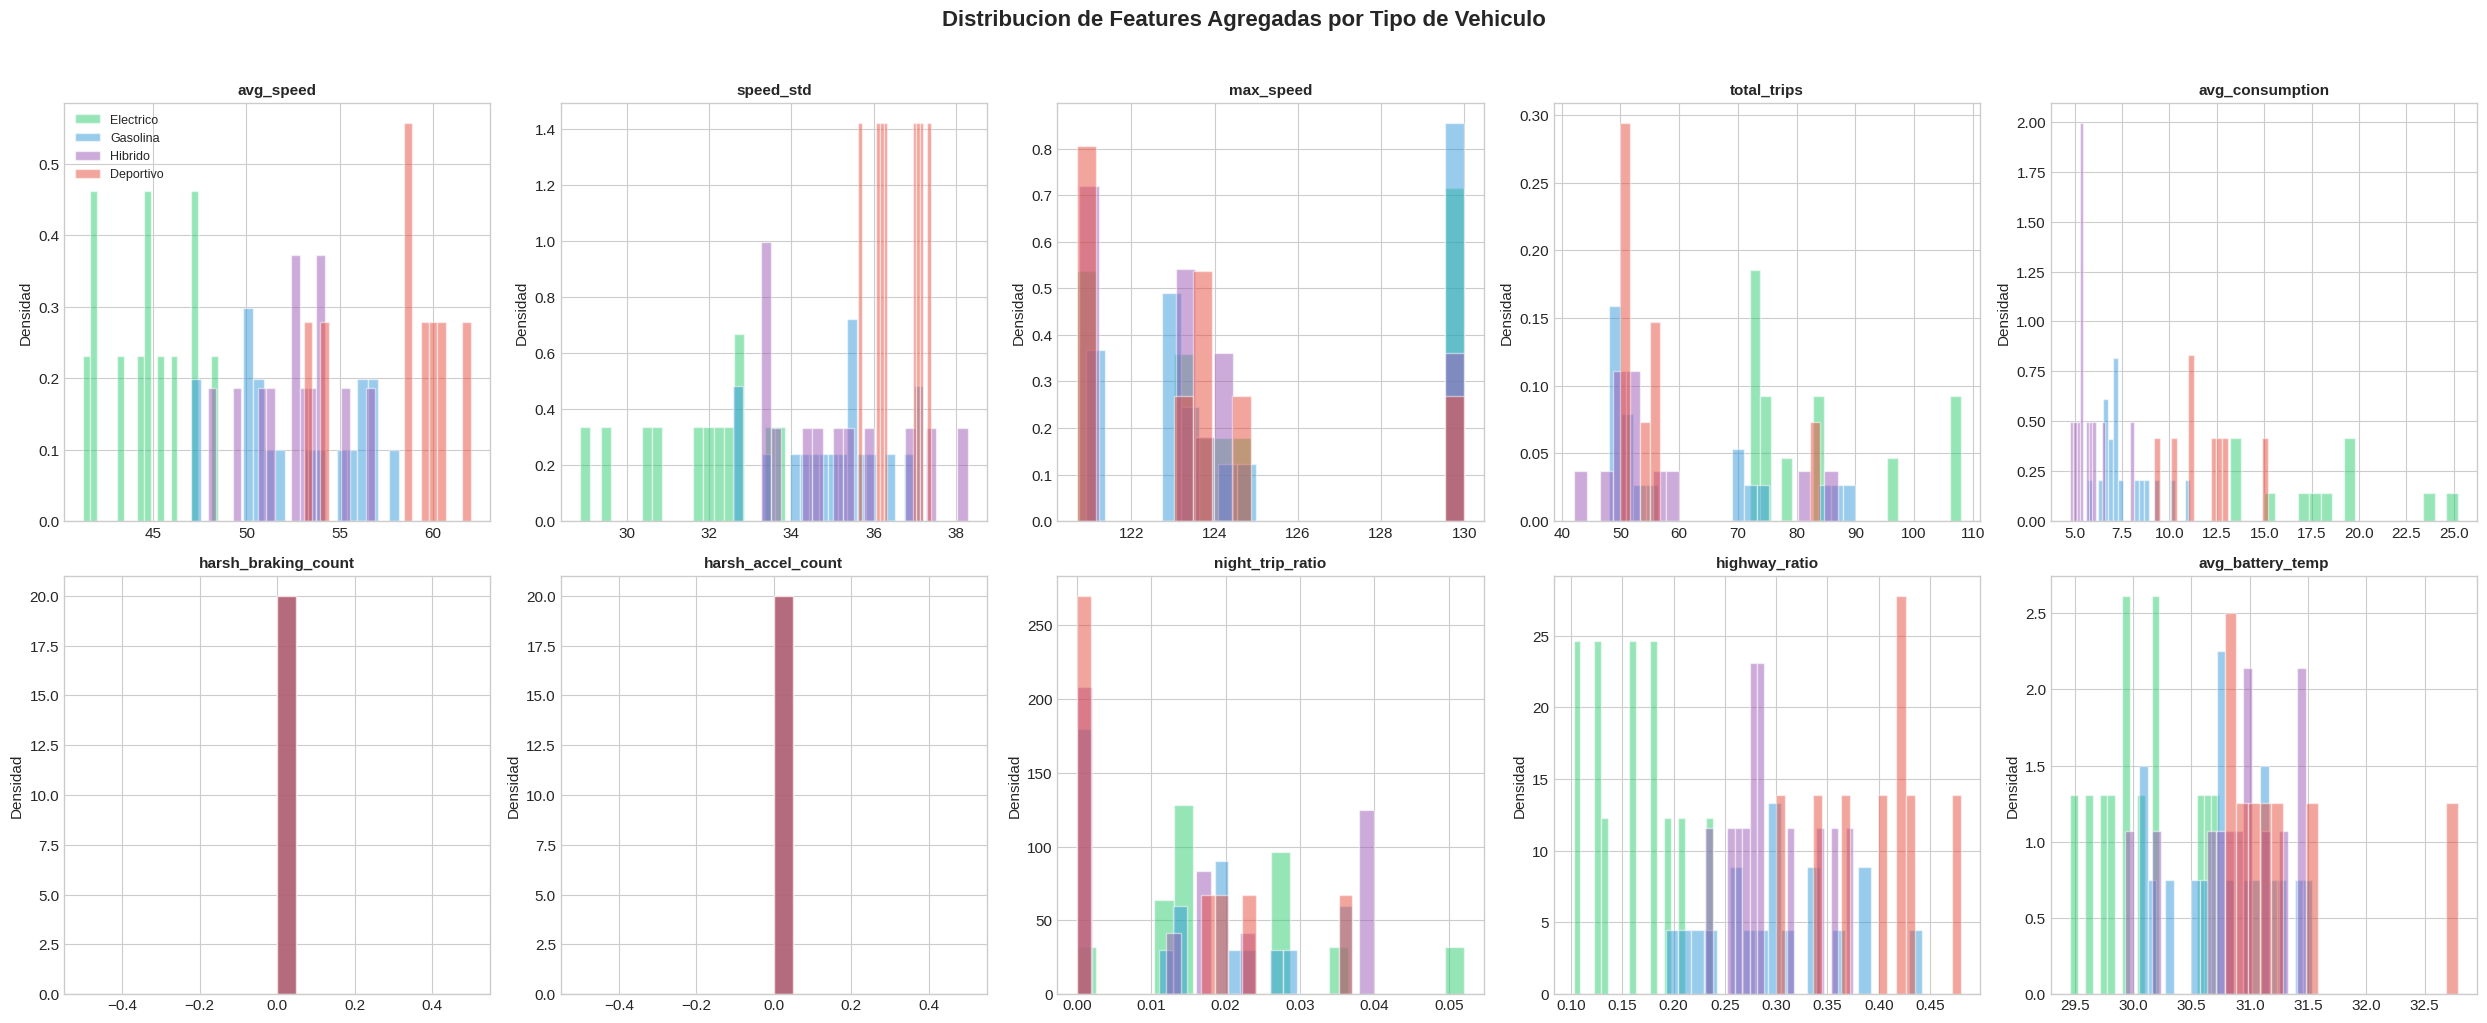

Observaciones:
- Las distribuciones varian significativamente por tipo de vehiculo
- Features como harsh_braking y harsh_accel capturan estilo de conduccion
- night_trip_ratio y highway_ratio capturan patrones de uso


In [6]:
# Visualizar distribuciones de features clave
key_features = ['avg_speed', 'speed_std', 'max_speed', 'total_trips',
                'avg_consumption', 'harsh_braking_count', 'harsh_accel_count',
                'night_trip_ratio', 'highway_ratio', 'avg_battery_temp']

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.ravel()

for ax, feat in zip(axes, key_features):
    for vtype, color in vtype_colors.items():
        subset = vehicle_features[vehicle_features['vehicle_type'] == vtype]
        ax.hist(subset[feat], bins=20, alpha=0.5, color=color, label=vtype.capitalize(),
                density=True, edgecolor='white')
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.set_ylabel('Densidad')

axes[0].legend(fontsize=9)
plt.suptitle('Distribucion de Features Agregadas por Tipo de Vehiculo',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Observaciones:")
print("- Las distribuciones varian significativamente por tipo de vehiculo")
print("- Features como harsh_braking y harsh_accel capturan estilo de conduccion")
print("- night_trip_ratio y highway_ratio capturan patrones de uso")

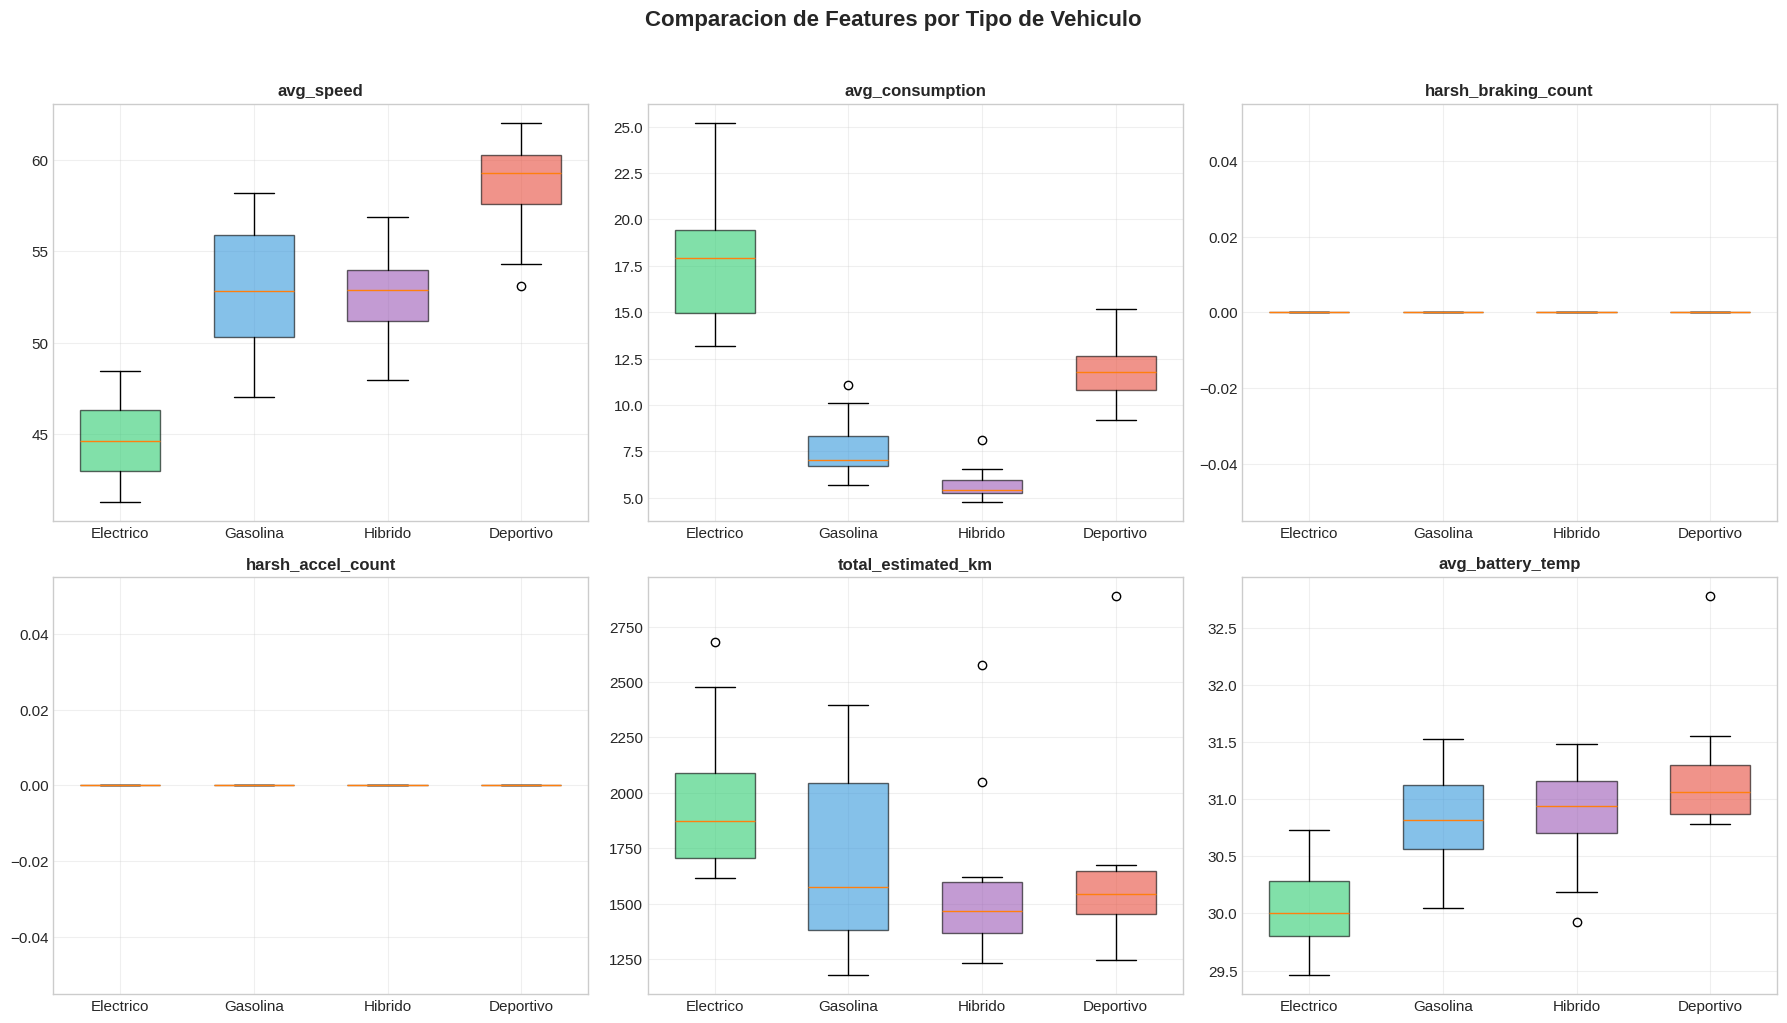

In [7]:
# Boxplots comparativos por tipo de vehiculo
compare_features = ['avg_speed', 'avg_consumption', 'harsh_braking_count',
                    'harsh_accel_count', 'total_estimated_km', 'avg_battery_temp']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, feat in zip(axes, compare_features):
    data_plot = [vehicle_features[vehicle_features['vehicle_type'] == vt][feat].dropna()
                 for vt in vtype_colors.keys()]
    bp = ax.boxplot(data_plot, labels=[vt.capitalize() for vt in vtype_colors.keys()],
                    patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], vtype_colors.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Comparacion de Features por Tipo de Vehiculo',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Features de ratio e interaccion

Los ratios y las interacciones capturan relaciones **no lineales** entre variables que un modelo lineal no podria encontrar por si solo.

- **Ratio**: normaliza una variable por otra, revelando eficiencia
- **Interaccion**: el producto de dos features, captura efectos combinados

In [8]:
# Ratio features
vehicle_features['speed_consumption_ratio'] = (
    vehicle_features['avg_speed'] / vehicle_features['avg_consumption'].replace(0, np.nan)
)

vehicle_features['braking_per_km'] = (
    vehicle_features['harsh_braking_count'] / vehicle_features['total_estimated_km'].replace(0, np.nan)
)

# Interaccion: conduccion nocturna en autopista
vehicle_features['night_highway_interaction'] = (
    vehicle_features['night_trip_ratio'] * vehicle_features['highway_ratio']
)

new_features = ['speed_consumption_ratio', 'braking_per_km', 'night_highway_interaction']

print("Nuevas features de ratio e interaccion:")
for feat in new_features:
    stats_desc = vehicle_features[feat].describe()
    print(f"\n  {feat}:")
    print(f"    Media: {stats_desc['mean']:.4f}, Std: {stats_desc['std']:.4f}")
    print(f"    Min: {stats_desc['min']:.4f}, Max: {stats_desc['max']:.4f}")

Nuevas features de ratio e interaccion:

  speed_consumption_ratio:
    Media: 6.2267, Std: 2.6654
    Min: 1.7643, Max: 11.2310

  braking_per_km:
    Media: 0.0000, Std: 0.0000
    Min: 0.0000, Max: 0.0000

  night_highway_interaction:
    Media: 0.0044, Std: 0.0042
    Min: 0.0000, Max: 0.0144


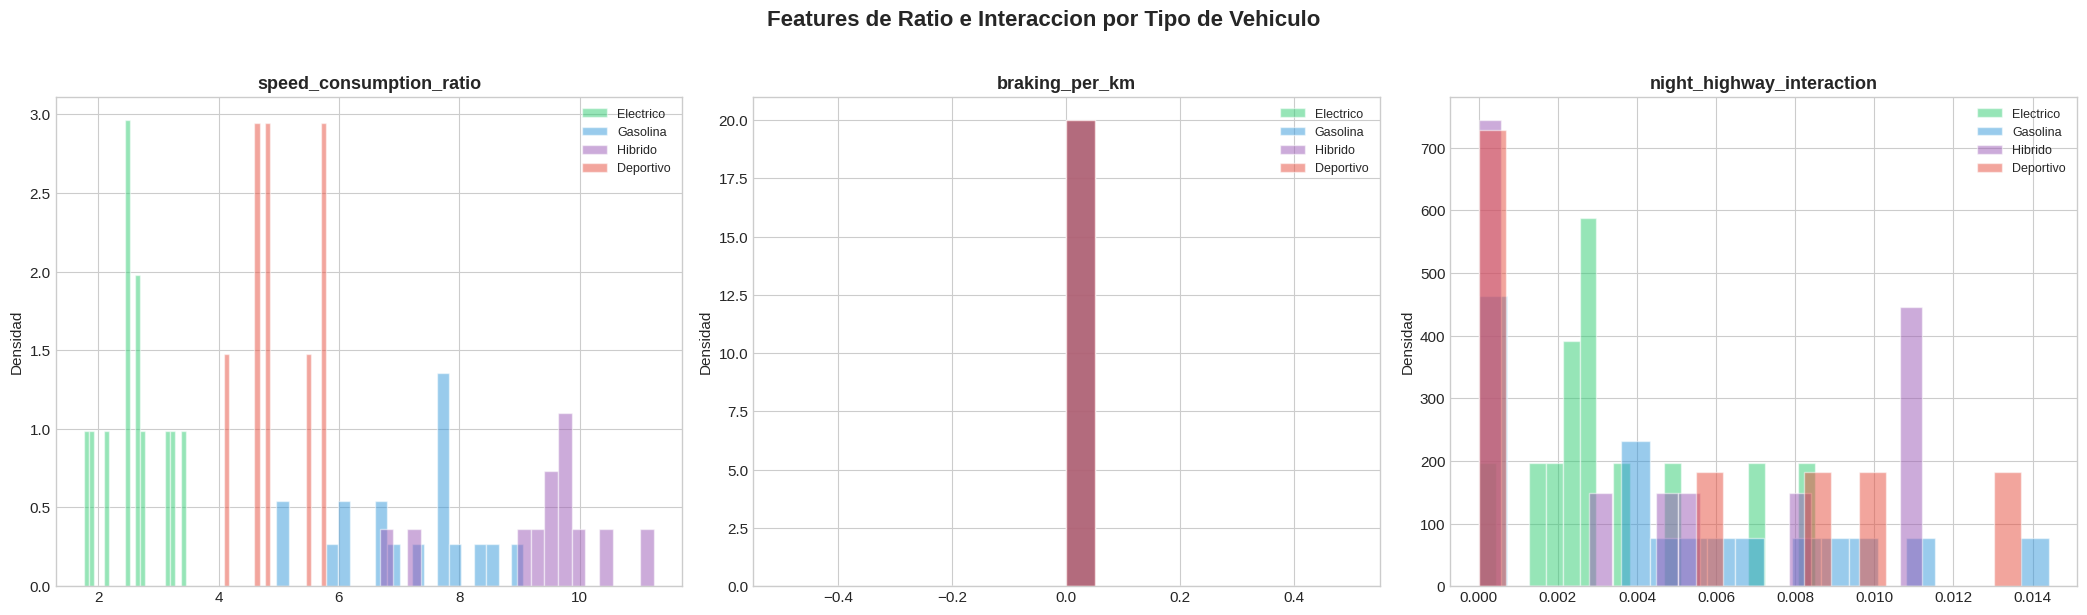

In [9]:
# Visualizar las nuevas features
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, feat in zip(axes, new_features):
    for vtype, color in vtype_colors.items():
        subset = vehicle_features[vehicle_features['vehicle_type'] == vtype]
        ax.hist(subset[feat].dropna(), bins=20, alpha=0.5, color=color,
                label=vtype.capitalize(), density=True, edgecolor='white')
    ax.set_title(feat, fontsize=13, fontweight='bold')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

plt.suptitle('Features de Ratio e Interaccion por Tipo de Vehiculo',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

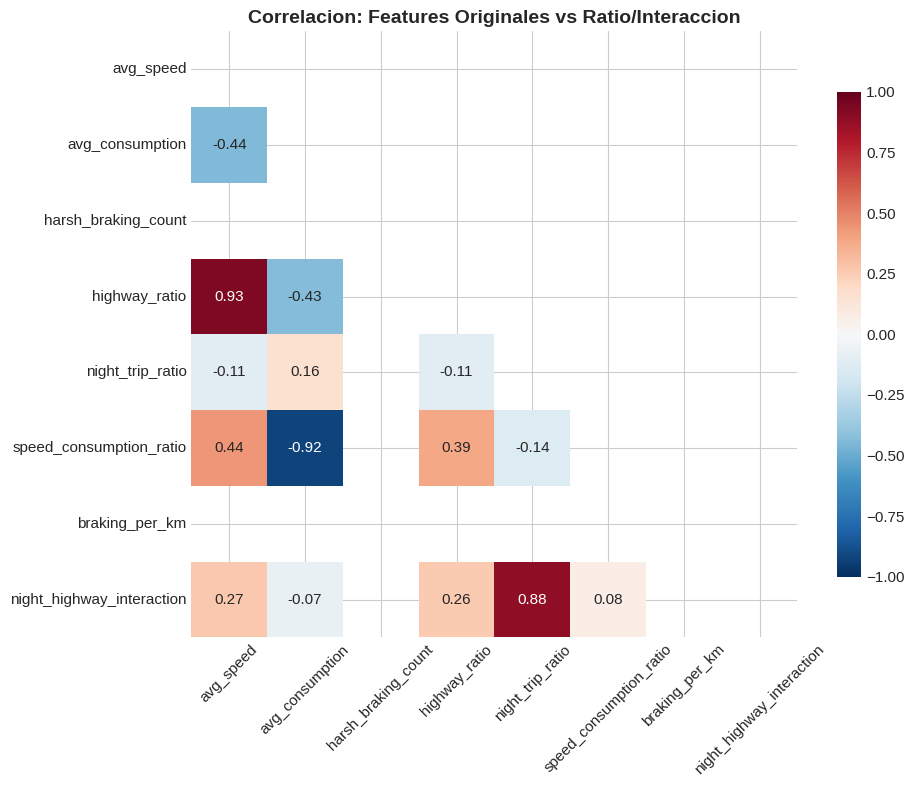

Las features de ratio aportan informacion diferente a las originales
cuando su correlacion con las componentes es moderada (no perfecta).


In [10]:
# Correlacion entre las nuevas features y las originales
ratio_and_key = ['avg_speed', 'avg_consumption', 'harsh_braking_count',
                 'highway_ratio', 'night_trip_ratio',
                 'speed_consumption_ratio', 'braking_per_km', 'night_highway_interaction']

corr_ratio = vehicle_features[ratio_and_key].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_ratio, dtype=bool))
sns.heatmap(corr_ratio, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlacion: Features Originales vs Ratio/Interaccion',
             fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("Las features de ratio aportan informacion diferente a las originales")
print("cuando su correlacion con las componentes es moderada (no perfecta).")

## 4. Features temporales

Los patrones de uso temporal revelan el **proposito** del vehiculo:
- Vehiculos de commute tienen picos en horas laborales
- Vehiculos recreativos se usan mas en fines de semana
- La distribucion por dia de semana muestra habitos del conductor

In [11]:
# Extraer features temporales del timestamp
telemetry['day_of_week'] = telemetry['timestamp'].dt.dayofweek  # 0=Lunes, 6=Domingo
telemetry['is_weekend'] = telemetry['day_of_week'].isin([5, 6]).astype(int)
telemetry['is_morning_commute'] = telemetry['hour'].between(7, 9).astype(int)  # 7-9h
telemetry['is_evening_commute'] = telemetry['hour'].between(17, 19).astype(int)  # 17-19h

# Agregar por vehiculo
temporal_features = telemetry.groupby('vehicle_id').agg(
    weekend_ratio=('is_weekend', 'mean'),
    morning_commute_ratio=('is_morning_commute', 'mean'),
    evening_commute_ratio=('is_evening_commute', 'mean'),
).reset_index()

# Distribucion por dia de semana (proporcion de registros en cada dia)
dow_counts = telemetry.groupby(['vehicle_id', 'day_of_week']).size().unstack(fill_value=0)
dow_ratios = dow_counts.div(dow_counts.sum(axis=1), axis=0)
dow_ratios.columns = [f'dow_{i}_ratio' for i in range(7)]
dow_ratios = dow_ratios.reset_index()

# Merge con vehicle_features
vehicle_features = vehicle_features.merge(temporal_features, on='vehicle_id')
vehicle_features = vehicle_features.merge(dow_ratios, on='vehicle_id')

temporal_cols = ['weekend_ratio', 'morning_commute_ratio', 'evening_commute_ratio']
print("Features temporales creadas:")
vehicle_features[['vehicle_id', 'vehicle_type'] + temporal_cols].head(10)

Features temporales creadas:


,vehicle_id,vehicle_type,weekend_ratio,morning_commute_ratio,evening_commute_ratio
0,01cb4faa-246c-4ac4-967e-686646c718d0,deportivo,0.294121,0.374379,0.269532
1,05d940bb-0a44-4770-a2e0-465a8504b31e,hibrido,0.330227,0.473417,0.270776
2,0ec4f37e-68a2-4f11-b8d3-afa45ce8883e,hibrido,0.275260,0.280548,0.328448
3,0f83af6a-2312-4c76-9431-140c10b597c7,deportivo,0.228568,0.412138,0.231760
4,1b176ac7-e470-49a6-b1a5-b4c153f1f324,gasolina,0.313719,0.270908,0.281980
5,1c91e357-95b4-42db-9014-a8c49b4c1063,hibrido,0.220661,0.331268,0.343764
6,286da00f-b0eb-476e-805a-01227025b3c9,gasolina,0.323162,0.245349,0.358616
7,3546a3c4-e3ba-4233-9251-8b482ad35ee5,gasolina,0.230228,0.393826,0.246831
8,3a9ee1b6-32f0-410a-8211-9d9ff27add0e,hibrido,0.217520,0.353857,0.266156
9,3bce6fcb-facc-407f-a458-188e4767536f,deportivo,0.210810,0.308931,0.336330


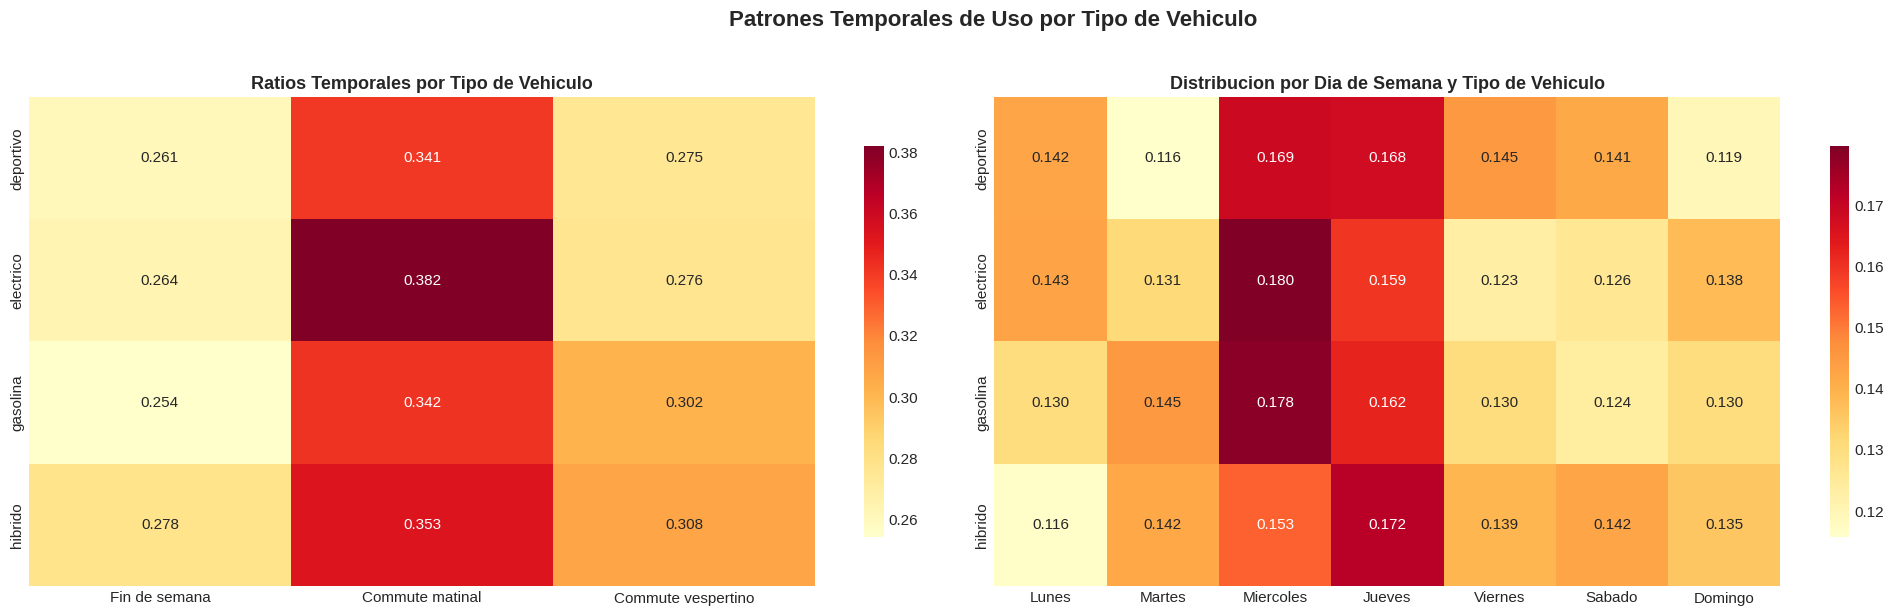

Observaciones:
- El ratio de fin de semana puede revelar uso recreativo vs laboral
- Los patrones de commute matinal/vespertino identifican vehiculos de transporte diario
- La distribucion por dia de semana muestra regularidad de uso


In [12]:
# Heatmap de features temporales por tipo de vehiculo
temporal_by_type = vehicle_features.groupby('vehicle_type')[temporal_cols].mean()

# Agregar dow ratios al heatmap
dow_cols = [f'dow_{i}_ratio' for i in range(7)]
dow_by_type = vehicle_features.groupby('vehicle_type')[dow_cols].mean()
dow_by_type.columns = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Heatmap de ratios temporales
ax = axes[0]
temporal_by_type.columns = ['Fin de semana', 'Commute matinal', 'Commute vespertino']
sns.heatmap(temporal_by_type, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Ratios Temporales por Tipo de Vehiculo', fontsize=13, fontweight='bold')
ax.set_ylabel('')

# Heatmap de distribucion por dia de semana
ax = axes[1]
sns.heatmap(dow_by_type, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Distribucion por Dia de Semana y Tipo de Vehiculo', fontsize=13, fontweight='bold')
ax.set_ylabel('')

plt.suptitle('Patrones Temporales de Uso por Tipo de Vehiculo',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Observaciones:")
print("- El ratio de fin de semana puede revelar uso recreativo vs laboral")
print("- Los patrones de commute matinal/vespertino identifican vehiculos de transporte diario")
print("- La distribucion por dia de semana muestra regularidad de uso")

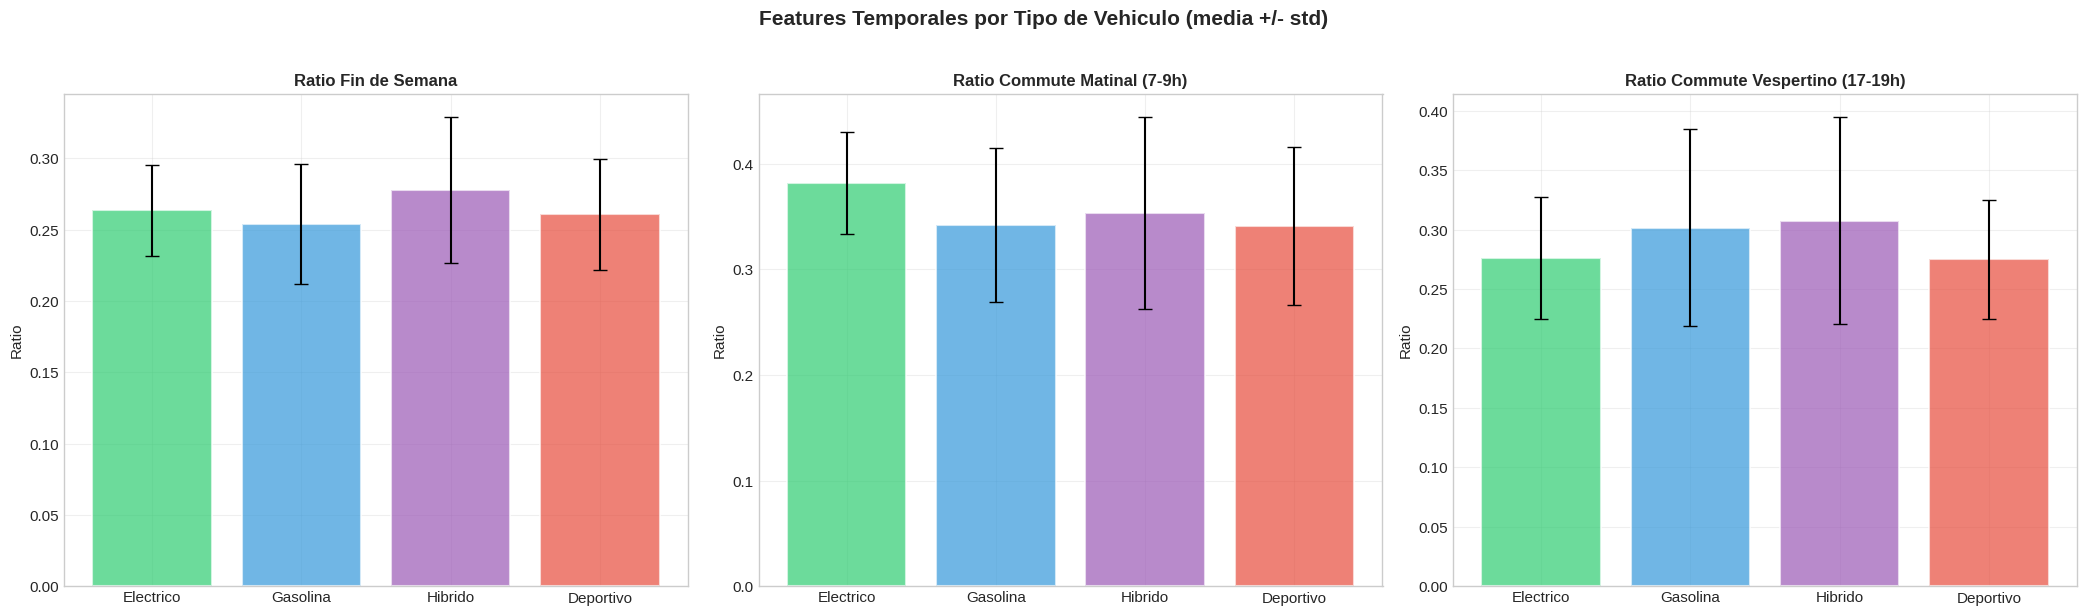

In [13]:
# Barplots agrupados de features temporales
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

temp_labels = ['weekend_ratio', 'morning_commute_ratio', 'evening_commute_ratio']
temp_titles = ['Ratio Fin de Semana', 'Ratio Commute Matinal (7-9h)', 'Ratio Commute Vespertino (17-19h)']

for ax, feat, title in zip(axes, temp_labels, temp_titles):
    means = []
    stds = []
    for vtype in vtype_colors.keys():
        subset = vehicle_features[vehicle_features['vehicle_type'] == vtype][feat]
        means.append(subset.mean())
        stds.append(subset.std())
    
    bars = ax.bar(range(len(vtype_colors)), means, yerr=stds,
                  color=list(vtype_colors.values()), alpha=0.7,
                  capsize=5, edgecolor='white', linewidth=1.5)
    ax.set_xticks(range(len(vtype_colors)))
    ax.set_xticklabels([vt.capitalize() for vt in vtype_colors.keys()])
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Ratio')
    ax.grid(True, alpha=0.3)

plt.suptitle('Features Temporales por Tipo de Vehiculo (media +/- std)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Encoding de variables categoricas

Los modelos de ML requieren datos numericos. Para convertir variables categoricas:

| Metodo | Uso | Ejemplo |
|--------|-----|----------|
| **Label Encoding** | Variables **ordinales** (con orden) | `income_bracket`: bajo=0, medio=1, alto=2 |
| **One-Hot Encoding** | Variables **nominales** (sin orden) | `vehicle_type`: 4 columnas binarias |

### ¿Cuando usar cada uno?
- **Label Encoding**: cuando la variable tiene un orden natural (bajo < medio < alto)
  - Ventaja: una sola columna
  - Riesgo: el modelo puede asumir distancias iguales entre categorias
- **One-Hot Encoding**: cuando NO hay orden natural (electrico, gasolina, hibrido)
  - Ventaja: no asume orden
  - Riesgo: aumenta dimensionalidad (N categorias = N-1 columnas con drop_first)

In [14]:
# Merge con encuestas para tener variables categoricas
# Agrupar encuestas por vehicle_id (tomar la primera encuesta si hay multiples)
survey_per_vehicle = surveys.groupby('vehicle_id').first().reset_index()

# Merge features del vehiculo con datos de encuesta
full_features = vehicle_features.merge(
    survey_per_vehicle[['vehicle_id', 'age', 'gender', 'income_bracket',
                        'purchase_reason', 'satisfaction_score', 'would_recommend',
                        'driving_style', 'expected_usage']],
    on='vehicle_id', how='left'
)

print(f"Dataset combinado: {full_features.shape}")
print(f"\nVariables categoricas disponibles:")
cat_cols = full_features.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    print(f"  {col}: {full_features[col].nunique()} categorias -> {full_features[col].unique()[:6]}")

Dataset combinado: (50, 37)

Variables categoricas disponibles:
  vehicle_id: 50 categorias -> <StringArray>
['01cb4faa-246c-4ac4-967e-686646c718d0',
 '05d940bb-0a44-4770-a2e0-465a8504b31e',
 '0ec4f37e-68a2-4f11-b8d3-afa45ce8883e',
 '0f83af6a-2312-4c76-9431-140c10b597c7',
 '1b176ac7-e470-49a6-b1a5-b4c153f1f324',
 '1c91e357-95b4-42db-9014-a8c49b4c1063']
Length: 6, dtype: str
  vehicle_type: 4 categorias -> <StringArray>
['deportivo', 'hibrido', 'gasolina', 'electrico']
Length: 4, dtype: str
  gender: 2 categorias -> <StringArray>
['masculino', 'femenino']
Length: 2, dtype: str
  income_bracket: 5 categorias -> <StringArray>
['medio-bajo', 'alto', 'medio', 'bajo', 'medio-alto']
Length: 5, dtype: str
  purchase_reason: 6 categorias -> <StringArray>
['economia', 'rendimiento', 'seguridad', 'estilo', 'ecologia', 'tecnologia']
Length: 6, dtype: str
  driving_style: 3 categorias -> <StringArray>
['normal', 'aggressive', 'calm']
Length: 3, dtype: str
  expected_usage: 3 categorias -> <StringAr

In [15]:
# ANTES del encoding: mostrar las variables categoricas
print("=== ANTES DEL ENCODING ===")
print("\nVariables ordinales (Label Encoding):")
if 'income_bracket' in full_features.columns:
    print(f"  income_bracket: {full_features['income_bracket'].value_counts().to_dict()}")
if 'driving_style' in full_features.columns:
    print(f"  driving_style:  {full_features['driving_style'].value_counts().to_dict()}")

print("\nVariables nominales (One-Hot Encoding):")
if 'vehicle_type' in full_features.columns:
    print(f"  vehicle_type:     {full_features['vehicle_type'].value_counts().to_dict()}")
if 'purchase_reason' in full_features.columns:
    print(f"  purchase_reason:  {full_features['purchase_reason'].value_counts().to_dict()}")
if 'gender' in full_features.columns:
    print(f"  gender:           {full_features['gender'].value_counts().to_dict()}")

=== ANTES DEL ENCODING ===

Variables ordinales (Label Encoding):
  income_bracket: {'medio-alto': 15, 'medio': 13, 'medio-bajo': 8, 'bajo': 8, 'alto': 6}
  driving_style:  {'normal': 23, 'aggressive': 14, 'calm': 13}

Variables nominales (One-Hot Encoding):
  vehicle_type:     {'gasolina': 18, 'hibrido': 12, 'electrico': 12, 'deportivo': 8}
  purchase_reason:  {'economia': 10, 'rendimiento': 10, 'ecologia': 10, 'seguridad': 9, 'estilo': 9, 'tecnologia': 2}
  gender:           {'femenino': 28, 'masculino': 22}


In [16]:
# Label Encoding para variables ordinales
# income_bracket: definir orden manualmente
income_order = {'bajo': 0, 'medio-bajo': 1, 'medio': 2, 'medio-alto': 3, 'alto': 4}
if 'income_bracket' in full_features.columns:
    # Mapear con el orden definido, si hay categorias no mapeadas usar LabelEncoder
    known_cats = set(income_order.keys())
    actual_cats = set(full_features['income_bracket'].dropna().unique())
    if actual_cats.issubset(known_cats):
        full_features['income_bracket_encoded'] = full_features['income_bracket'].map(income_order)
    else:
        le_income = LabelEncoder()
        full_features['income_bracket_encoded'] = le_income.fit_transform(
            full_features['income_bracket'].fillna('desconocido'))
        print(f"  income_bracket categorias: {dict(zip(le_income.classes_, le_income.transform(le_income.classes_)))}")

# driving_style: definir orden
driving_order = {'conservador': 0, 'moderado': 1, 'agresivo': 2, 'deportivo': 3}
if 'driving_style' in full_features.columns:
    actual_driving = set(full_features['driving_style'].dropna().unique())
    if actual_driving.issubset(set(driving_order.keys())):
        full_features['driving_style_encoded'] = full_features['driving_style'].map(driving_order)
    else:
        le_driving = LabelEncoder()
        full_features['driving_style_encoded'] = le_driving.fit_transform(
            full_features['driving_style'].fillna('desconocido'))
        print(f"  driving_style categorias: {dict(zip(le_driving.classes_, le_driving.transform(le_driving.classes_)))}")

print("Label Encoding aplicado a variables ordinales")

  driving_style categorias: {'aggressive': np.int64(0), 'calm': np.int64(1), 'normal': np.int64(2)}
Label Encoding aplicado a variables ordinales


In [17]:
# One-Hot Encoding para variables nominales
nominal_cols = []
for col in ['vehicle_type', 'purchase_reason', 'gender', 'expected_usage']:
    if col in full_features.columns:
        nominal_cols.append(col)

# Aplicar one-hot encoding con drop_first para evitar multicolinealidad
full_encoded = pd.get_dummies(full_features, columns=nominal_cols, drop_first=True, dtype=int)

# Eliminar columnas categoricas originales que ya fueron codificadas (ordinales)
cols_to_drop = [c for c in ['income_bracket', 'driving_style'] if c in full_encoded.columns]
full_encoded = full_encoded.drop(columns=cols_to_drop)

print(f"Shape antes del encoding:  {full_features.shape}")
print(f"Shape despues del encoding: {full_encoded.shape}")
print(f"\nColumnas nuevas (one-hot):")
ohe_cols = [c for c in full_encoded.columns if any(c.startswith(f'{nom}_') for nom in nominal_cols)]
for col in ohe_cols:
    print(f"  {col}: {full_encoded[col].sum()} vehiculos")

Shape antes del encoding:  (50, 39)
Shape despues del encoding: (50, 44)

Columnas nuevas (one-hot):
  vehicle_type_electrico: 12 vehiculos
  vehicle_type_gasolina: 18 vehiculos
  vehicle_type_hibrido: 12 vehiculos
  purchase_reason_economia: 10 vehiculos
  purchase_reason_estilo: 9 vehiculos
  purchase_reason_rendimiento: 10 vehiculos
  purchase_reason_seguridad: 9 vehiculos
  purchase_reason_tecnologia: 2 vehiculos
  gender_masculino: 22 vehiculos
  expected_usage_ciudad: 25 vehiculos
  expected_usage_mixto: 14 vehiculos


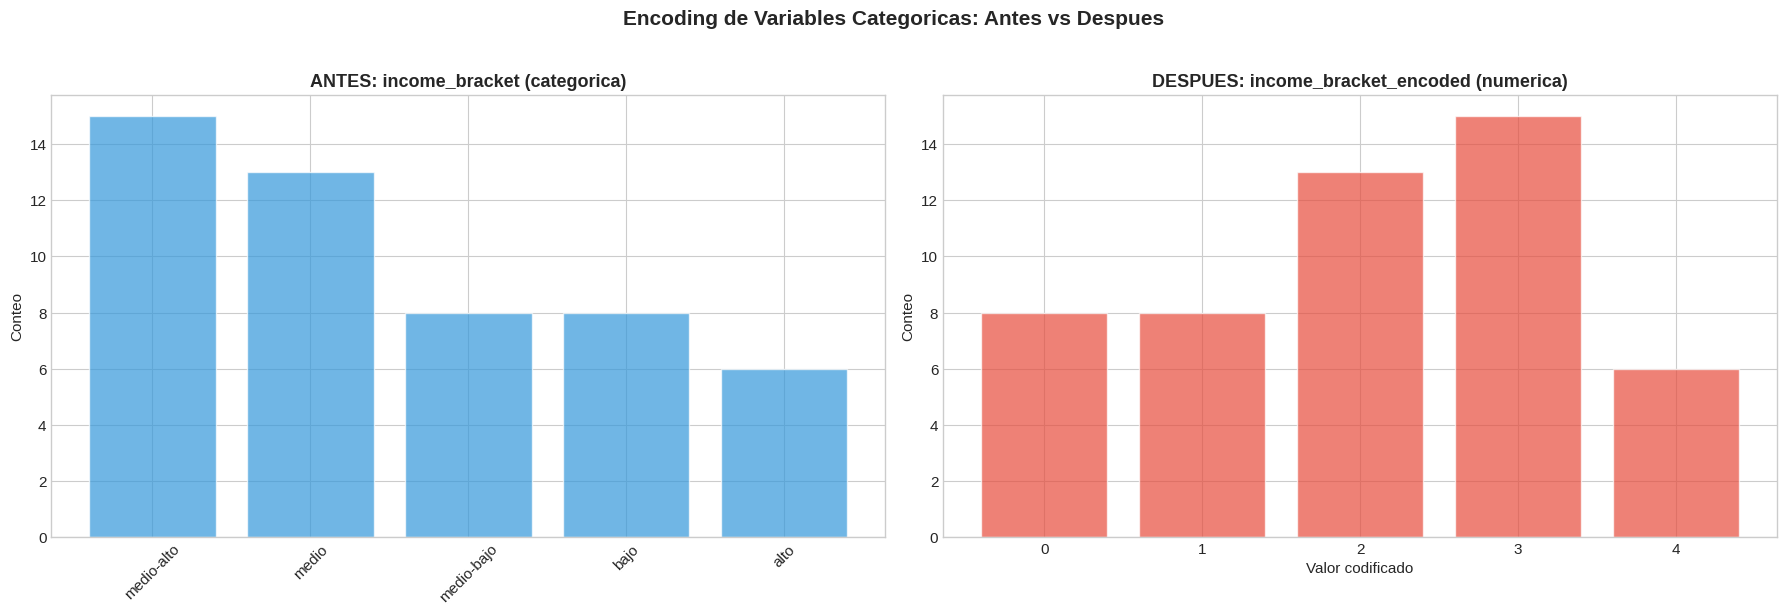

In [18]:
# Visualizar: ANTES vs DESPUES del encoding
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Antes: distribucion de income_bracket (categorica)
ax = axes[0]
if 'income_bracket' in full_features.columns:
    counts = full_features['income_bracket'].value_counts()
    ax.bar(range(len(counts)), counts.values, color='#3498db', alpha=0.7, edgecolor='white')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45)
    ax.set_title('ANTES: income_bracket (categorica)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Conteo')
else:
    ax.text(0.5, 0.5, 'income_bracket no disponible', ha='center', va='center',
            transform=ax.transAxes, fontsize=12)
    ax.set_title('ANTES: Variable categorica', fontsize=13, fontweight='bold')

# Despues: distribucion de income_bracket_encoded (numerica)
ax = axes[1]
if 'income_bracket_encoded' in full_encoded.columns:
    encoded_counts = full_encoded['income_bracket_encoded'].value_counts().sort_index()
    ax.bar(encoded_counts.index, encoded_counts.values, color='#e74c3c', alpha=0.7, edgecolor='white')
    ax.set_xlabel('Valor codificado')
    ax.set_title('DESPUES: income_bracket_encoded (numerica)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Conteo')
else:
    # Mostrar one-hot encoding como ejemplo
    vtype_ohe = [c for c in full_encoded.columns if c.startswith('vehicle_type_')]
    if vtype_ohe:
        sums = full_encoded[vtype_ohe].sum()
        ax.bar(range(len(sums)), sums.values, color='#e74c3c', alpha=0.7, edgecolor='white')
        ax.set_xticks(range(len(sums)))
        ax.set_xticklabels([c.replace('vehicle_type_', '') for c in vtype_ohe], rotation=45)
        ax.set_title('DESPUES: vehicle_type (one-hot)', fontsize=13, fontweight='bold')
        ax.set_ylabel('Conteo')

plt.suptitle('Encoding de Variables Categoricas: Antes vs Despues',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Feature Selection

No todas las features son utiles. Aplicamos dos filtros:

1. **Filtro por correlacion**: si dos features tienen |r| > 0.9, eliminamos una (son redundantes)
2. **Filtro por varianza**: si una feature tiene varianza casi cero, no aporta informacion

Finalmente, usamos un Random Forest para obtener una vista previa de la importancia de cada feature.

In [19]:
# Preparar dataset numerico para feature selection
exclude_cols = ['vehicle_id']
numeric_features = full_encoded.drop(columns=exclude_cols, errors='ignore')
numeric_features = numeric_features.select_dtypes(include=[np.number])

# Eliminar filas con NaN para el analisis
numeric_clean = numeric_features.dropna()

print(f"Features numericas: {numeric_clean.shape[1]}")
print(f"Observaciones completas: {numeric_clean.shape[0]}")

Features numericas: 42
Observaciones completas: 50


In [20]:
# 1. Filtro por correlacion: encontrar pares con |r| > 0.9
corr_matrix = numeric_clean.corr().abs()

# Encontrar pares altamente correlacionados
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        if upper_tri.loc[idx, col] > 0.9:
            high_corr_pairs.append({
                'Feature 1': idx,
                'Feature 2': col,
                '|Correlacion|': upper_tri.loc[idx, col]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('|Correlacion|', ascending=False)
    print(f"Pares con |r| > 0.9 (candidatos a eliminar):")
    print(high_corr_df.round(4).to_string(index=False))
    
    # Eliminar la segunda feature de cada par altamente correlacionado
    cols_to_remove = set()
    for _, row in high_corr_df.iterrows():
        if row['Feature 1'] not in cols_to_remove:
            cols_to_remove.add(row['Feature 2'])
    
    print(f"\nFeatures a eliminar por alta correlacion: {cols_to_remove}")
    numeric_filtered = numeric_clean.drop(columns=list(cols_to_remove))
else:
    print("No se encontraron pares con |r| > 0.9")
    cols_to_remove = set()
    numeric_filtered = numeric_clean.copy()

print(f"\nFeatures antes: {numeric_clean.shape[1]} -> despues: {numeric_filtered.shape[1]}")

Pares con |r| > 0.9 (candidatos a eliminar):
      Feature 1               Feature 2  |Correlacion|
avg_consumption         consumption_std         0.9691
      speed_std           highway_ratio         0.9318
      avg_speed           highway_ratio         0.9305
avg_consumption speed_consumption_ratio         0.9233

Features a eliminar por alta correlacion: {'speed_consumption_ratio', 'consumption_std', 'highway_ratio'}

Features antes: 42 -> despues: 39


In [21]:
# 2. Filtro por varianza
selector = VarianceThreshold(threshold=0.01)  # eliminar features con varianza < 0.01
selector.fit(numeric_filtered)

low_var_features = numeric_filtered.columns[~selector.get_support()].tolist()
high_var_features = numeric_filtered.columns[selector.get_support()].tolist()

if low_var_features:
    print(f"Features con varianza < 0.01 (eliminadas): {low_var_features}")
    for feat in low_var_features:
        print(f"  {feat}: var = {numeric_filtered[feat].var():.6f}")
else:
    print("Todas las features tienen varianza suficiente (> 0.01)")

numeric_selected = numeric_filtered[high_var_features]
print(f"\nFeatures finales despues de ambos filtros: {numeric_selected.shape[1]}")

Features con varianza < 0.01 (eliminadas): ['harsh_braking_count', 'harsh_accel_count', 'night_trip_ratio', 'braking_per_km', 'night_highway_interaction', 'weekend_ratio', 'morning_commute_ratio', 'evening_commute_ratio', 'dow_0_ratio', 'dow_1_ratio', 'dow_2_ratio', 'dow_3_ratio', 'dow_4_ratio', 'dow_5_ratio', 'dow_6_ratio']
  harsh_braking_count: var = 0.000000
  harsh_accel_count: var = 0.000000
  night_trip_ratio: var = 0.000197
  braking_per_km: var = 0.000000
  night_highway_interaction: var = 0.000018
  weekend_ratio: var = 0.001734
  morning_commute_ratio: var = 0.005290
  evening_commute_ratio: var = 0.005223
  dow_0_ratio: var = 0.001476
  dow_1_ratio: var = 0.000897
  dow_2_ratio: var = 0.000925
  dow_3_ratio: var = 0.000912
  dow_4_ratio: var = 0.001458
  dow_5_ratio: var = 0.000995
  dow_6_ratio: var = 0.000889

Features finales despues de ambos filtros: 24


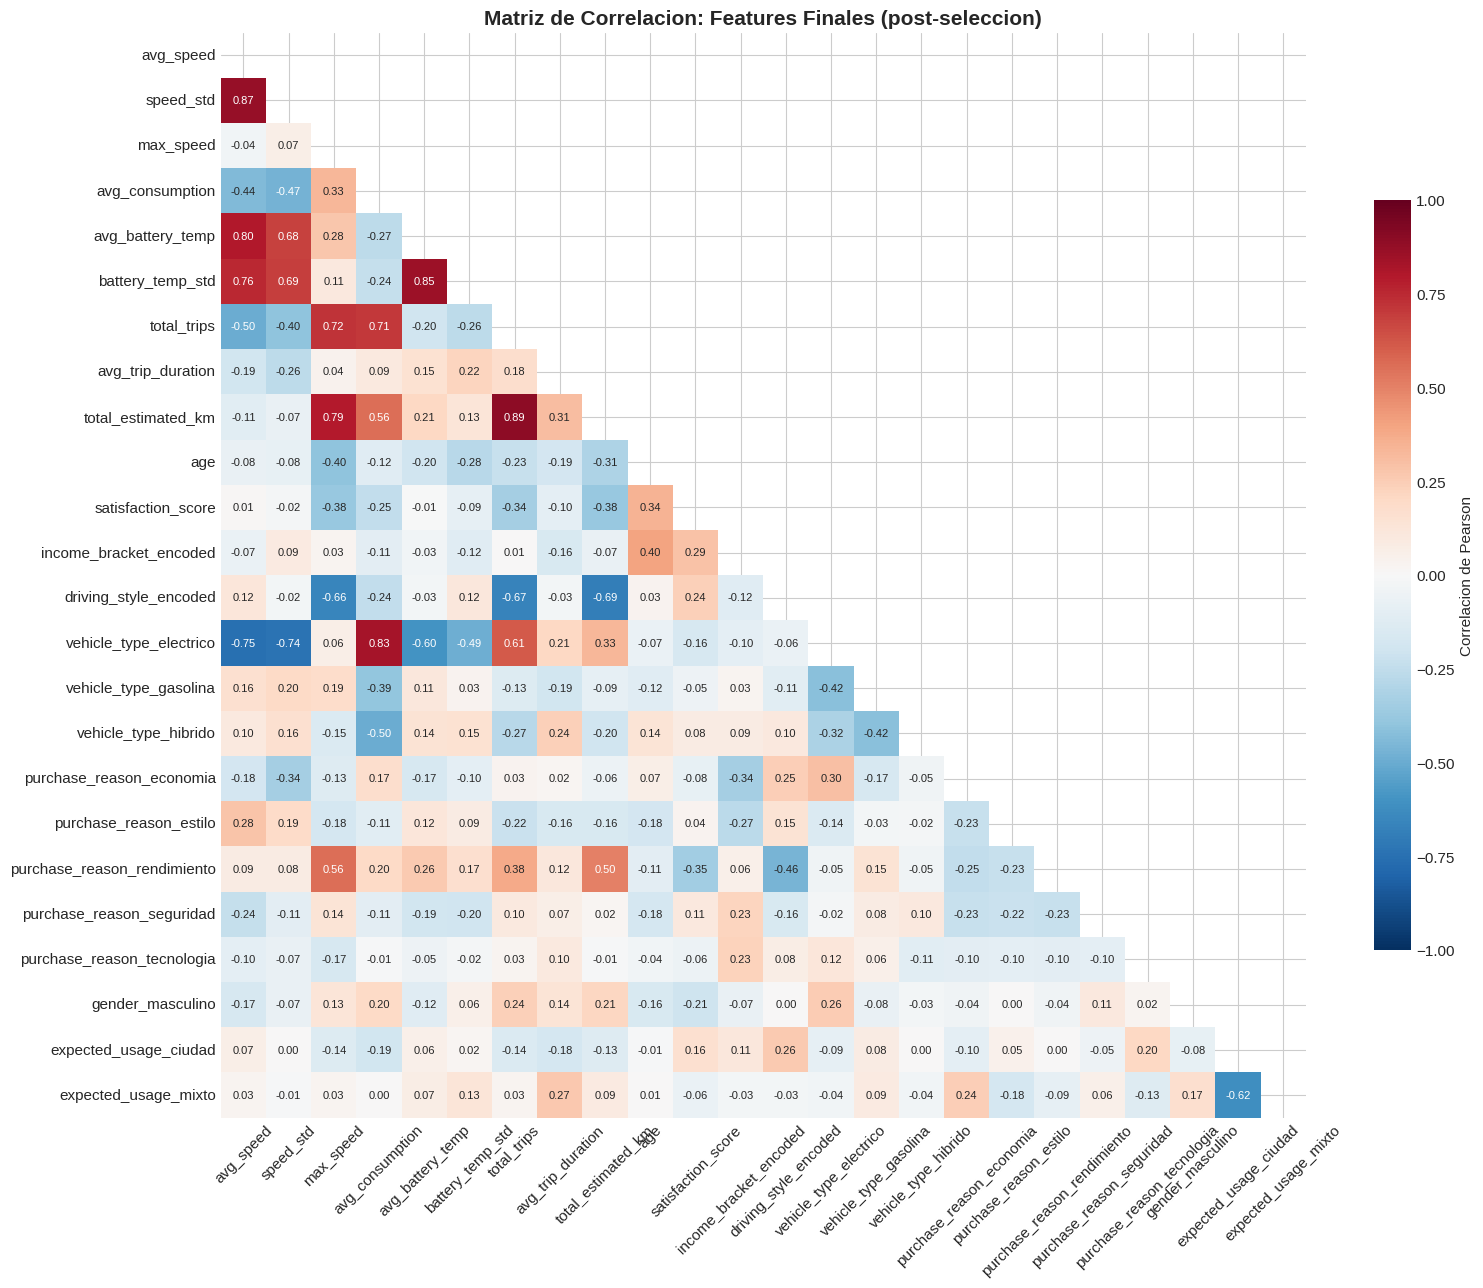

Dimensiones del dataset final: (50, 24)
Maximo |r| entre features (excluyendo diagonal): 0.893


In [22]:
# Matriz de correlacion del dataset final
final_corr = numeric_selected.corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(final_corr, dtype=bool))
sns.heatmap(final_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            annot_kws={'size': 8},
            cbar_kws={'shrink': 0.6, 'label': 'Correlacion de Pearson'})
ax.set_title('Matriz de Correlacion: Features Finales (post-seleccion)',
             fontsize=15, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

print(f"Dimensiones del dataset final: {numeric_selected.shape}")
print(f"Maximo |r| entre features (excluyendo diagonal): {final_corr.where(~np.eye(len(final_corr), dtype=bool)).abs().max().max():.3f}")

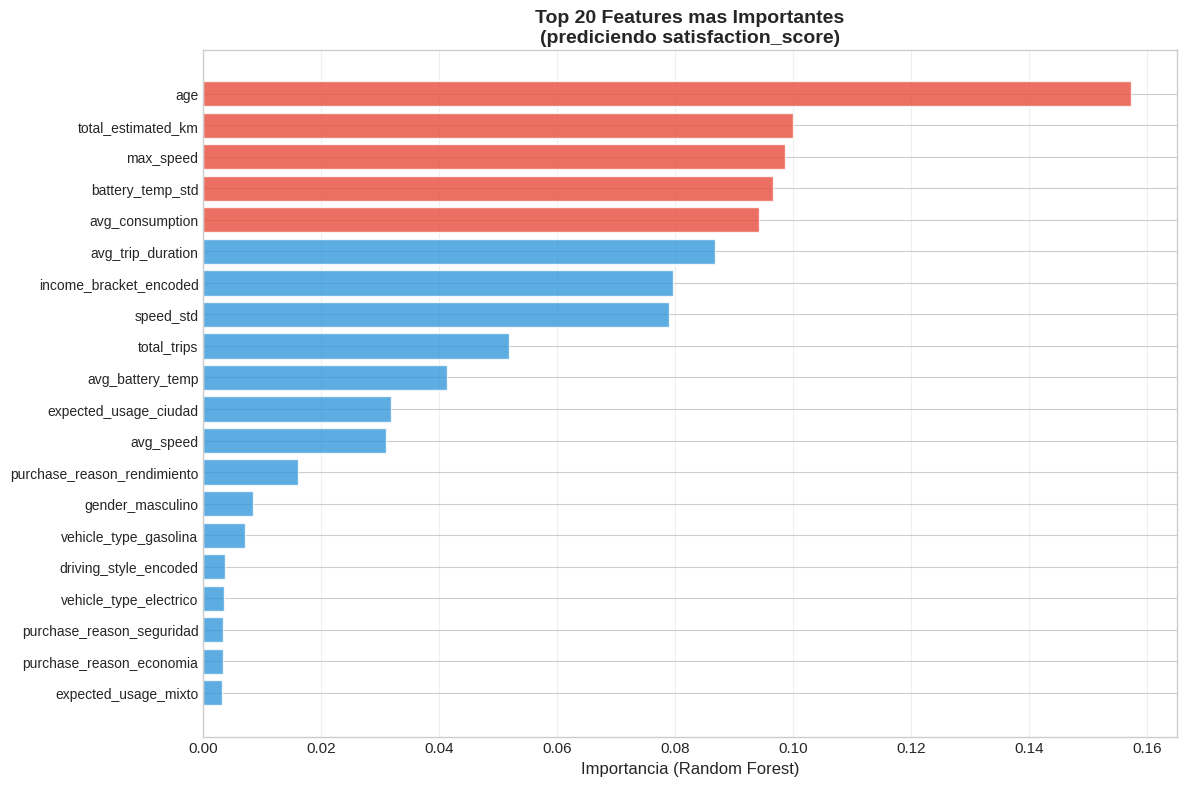

R2 del Random Forest (train): 0.8740

Top 10 features:
  avg_battery_temp: 0.0413
  total_trips: 0.0518
  speed_std: 0.0789
  income_bracket_encoded: 0.0796
  avg_trip_duration: 0.0867
  avg_consumption: 0.0941
  battery_temp_std: 0.0966
  max_speed: 0.0985
  total_estimated_km: 0.1000
  age: 0.1572


In [23]:
# Feature importance preview con Random Forest
# Predecir satisfaction_score como variable objetivo de ejemplo
target_col = 'satisfaction_score'

if target_col in numeric_selected.columns:
    feature_cols = [c for c in numeric_selected.columns if c != target_col]
    X = numeric_selected[feature_cols]
    y = numeric_selected[target_col]
    
    # Eliminar filas con NaN
    valid = X.notna().all(axis=1) & y.notna()
    X_valid = X[valid]
    y_valid = y[valid]
    
    if len(X_valid) > 20:
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
        rf.fit(X_valid, y_valid)
        
        importances = pd.Series(rf.feature_importances_, index=feature_cols)
        importances = importances.sort_values(ascending=True)
        
        # Top 20 features
        top_n = min(20, len(importances))
        top_imp = importances.tail(top_n)
        
        fig, ax = plt.subplots(figsize=(12, max(8, top_n * 0.4)))
        colors = ['#e74c3c' if imp > top_imp.quantile(0.75) else '#3498db' for imp in top_imp.values]
        ax.barh(range(len(top_imp)), top_imp.values, color=colors, alpha=0.8, edgecolor='white')
        ax.set_yticks(range(len(top_imp)))
        ax.set_yticklabels(top_imp.index, fontsize=10)
        ax.set_xlabel('Importancia (Random Forest)', fontsize=12)
        ax.set_title(f'Top {top_n} Features mas Importantes\n(prediciendo {target_col})',
                     fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        plt.show()
        
        print(f"R2 del Random Forest (train): {rf.score(X_valid, y_valid):.4f}")
        print(f"\nTop 10 features:")
        for feat, imp in importances.tail(10).items():
            print(f"  {feat}: {imp:.4f}")
    else:
        print(f"Insuficientes datos validos para RF: {len(X_valid)} observaciones")
else:
    print(f"Variable objetivo '{target_col}' no encontrada en el dataset")
    print(f"Columnas disponibles: {list(numeric_selected.columns[:10])}...")

## 7. Guardar dataset de features

Guardamos el dataset con todas las features engineered, listo para modelado en los siguientes notebooks.

In [24]:
# Preparar dataset final para guardar
# Usamos full_encoded (con encoding) y eliminamos features redundantes
features_ml = full_encoded.drop(columns=list(cols_to_remove), errors='ignore')

# Eliminar features de baja varianza
if low_var_features:
    features_ml = features_ml.drop(columns=[c for c in low_var_features if c in features_ml.columns],
                                    errors='ignore')

# Guardar
output_path = os.path.join(processed_dir, "features_ml.csv")
os.makedirs(processed_dir, exist_ok=True)
features_ml.to_csv(output_path, index=False)

print(f"Dataset guardado en: {output_path}")
print(f"\nShape final: {features_ml.shape}")
print(f"  - Filas (vehiculos): {features_ml.shape[0]}")
print(f"  - Columnas (features): {features_ml.shape[1]}")
print(f"\nColumnas finales ({features_ml.shape[1]}):")
for i, col in enumerate(features_ml.columns, 1):
    dtype = features_ml[col].dtype
    null_pct = features_ml[col].isnull().mean() * 100
    print(f"  {i:2d}. {col:<35} ({dtype}, {null_pct:.1f}% nulos)")

Dataset guardado en: /home/danielmf31/Documentos/Documentos_Trabajo/Ingenieria/Programacion/VSCode/Proyectos_personales/Ciencia_Datos/data/processed/features_ml.csv

Shape final: (50, 26)
  - Filas (vehiculos): 50
  - Columnas (features): 26

Columnas finales (26):
   1. vehicle_id                          (str, 0.0% nulos)
   2. avg_speed                           (float64, 0.0% nulos)
   3. speed_std                           (float64, 0.0% nulos)
   4. max_speed                           (float64, 0.0% nulos)
   5. avg_consumption                     (float64, 0.0% nulos)
   6. avg_battery_temp                    (float64, 0.0% nulos)
   7. battery_temp_std                    (float64, 0.0% nulos)
   8. total_trips                         (int64, 0.0% nulos)
   9. avg_trip_duration                   (float64, 0.0% nulos)
  10. total_estimated_km                  (float64, 0.0% nulos)
  11. age                                 (int64, 0.0% nulos)
  12. satisfaction_score              

In [25]:
# Verificacion: leer el archivo guardado
verification = pd.read_csv(output_path)
print(f"Verificacion de lectura: {verification.shape}")
print(f"\nPrimeras 3 filas:")
verification.head(3)

Verificacion de lectura: (50, 26)

Primeras 3 filas:


,vehicle_id,avg_speed,speed_std,max_speed,avg_consumption,avg_battery_temp,battery_temp_std,total_trips,avg_trip_duration,total_estimated_km,...,vehicle_type_gasolina,vehicle_type_hibrido,purchase_reason_economia,purchase_reason_estilo,purchase_reason_rendimiento,purchase_reason_seguridad,purchase_reason_tecnologia,gender_masculino,expected_usage_ciudad,expected_usage_mixto
0,01cb4faa-246c-4ac4-967e-686646c718d0,60.440368,36.220028,123.89,10.993354,31.215629,6.746110,54,30.121296,1639.394619,...,0,0,1,0,0,0,0,1,0,1
1,05d940bb-0a44-4770-a2e0-465a8504b31e,53.890560,34.455347,123.21,5.405120,30.847021,6.269641,52,29.661859,1386.140064,...,0,1,0,0,1,0,0,0,1,0
2,0ec4f37e-68a2-4f11-b8d3-afa45ce8883e,54.152179,36.877091,130.00,8.108978,31.470978,6.601335,87,32.802874,2577.011958,...,0,1,0,0,1,0,0,1,1,0


## Resumen

### Pipeline de Feature Engineering completado

| Etapa | Features creadas | Descripcion |
|-------|-----------------|-------------|
| **Agregaciones** | avg_speed, speed_std, max_speed, total_trips, avg_trip_duration, total_estimated_km, avg_consumption, consumption_std, harsh_braking_count, harsh_accel_count, night_trip_ratio, highway_ratio, avg_battery_temp, battery_temp_std | Estadisticas por vehiculo desde telemetria cruda |
| **Ratios/Interacciones** | speed_consumption_ratio, braking_per_km, night_highway_interaction | Relaciones entre features |
| **Temporales** | weekend_ratio, morning_commute_ratio, evening_commute_ratio, dow_0-6_ratio | Patrones de uso por tiempo |
| **Encoding** | income_bracket_encoded, driving_style_encoded + one-hot de vehicle_type, purchase_reason, gender | Categoricas a numericas |
| **Seleccion** | Filtro correlacion (>0.9), varianza threshold | Eliminar redundantes |

### Hallazgos clave
- Las features agregadas capturan diferencias claras entre tipos de vehiculo
- Los ratios (como speed_consumption_ratio) aportan informacion que las features individuales no contienen
- Los patrones temporales revelan el proposito del vehiculo (commute vs recreativo)
- El filtro de correlacion elimina features redundantes que podrian causar multicolinealidad
- El Random Forest da una primera vista de que features son mas predictivas

### Dataset generado
- **Archivo**: `data/processed/features_ml.csv`
- **Granularidad**: una fila por vehiculo
- **Listo para**: regresion, clasificacion, clustering

### Siguiente notebook
En `02_regression_fuel_consumption.ipynb` usaremos estas features para construir un modelo de regresion que prediga el consumo de combustible.